# Compile `[res, k_views, mean, median, p90]` from chunked CSV
This notebook cell parses the chunked CSV format:
- Header line contains `_res_<n>_k_views_<m>`
- Followed by `Mean`, `Median`, `P90` blocks
- For each block, we take the bottom-right entry: row `all` and column `all` (the last column in that row).

In [49]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, List, Dict, Tuple

import pandas as pd


HEADER_RE = re.compile(r"(?:^|_)res_(?P<res>\d+)_k_views_(?P<k_views>\d+)(?:$|\b|_)")


class ParseError(RuntimeError):
    pass


def _is_metric_label(line: str) -> bool:
    return line.strip() in {"Mean", "Median", "P90", "Log_Mean", "Log_Median", "Log_P90"}


def _looks_like_chunk_header(line: str) -> bool:
    line = line.strip()
    if not line:
        return False
    if _is_metric_label(line):
        return False
    if line.startswith("Problem Group"):
        return False
    return HEADER_RE.search(line) is not None


def _parse_chunk_header(line: str) -> Tuple[int, int]:
    m = HEADER_RE.search(line)
    if not m:
        raise ParseError(f"Could not find '_res_<n>_k_views_<n>' in header line: {line!r}")
    return int(m.group("res")), int(m.group("k_views"))


def _parse_metric_all_all(lines: List[str], start_idx: int, metric_name: str) -> Tuple[float, int]:
    """Parse one metric table starting at start_idx (line after metric label)."""
    i = start_idx
    while i < len(lines) and not lines[i].strip():
        i += 1
    if i >= len(lines) or not lines[i].lstrip().startswith("Problem Group"):
        got = lines[i].rstrip() if i < len(lines) else "<EOF>"
        raise ParseError(f"Expected 'Problem Group,...' header after {metric_name}, got: {got}")

    all_row: Optional[List[str]] = None
    i += 1  # skip table header
    while i < len(lines):
        raw = lines[i].rstrip("\n")
        stripped = raw.strip()
        if not stripped:
            break
        if _is_metric_label(stripped) or _looks_like_chunk_header(stripped):
            break
        # Parse as CSV row (handles commas safely)
        row = next(pd.read_csv(pd.io.common.StringIO(raw), header=None).itertuples(index=False, name=None))
        row = ["" if pd.isna(x) else str(x) for x in row]
        if row and str(row[0]).strip().lower() == "all":
            all_row = row
        i += 1

    if all_row is None:
        raise ParseError(f"Did not find 'all' row in {metric_name} table")
    value_str = str(all_row[-1]).strip()
    try:
        value = float(value_str)
    except ValueError as e:
        raise ParseError(f"Could not parse all/all value {value_str!r} in {metric_name}") from e
    return value, i


def compile_chunked_metrics_table(csv_path: str | Path) -> pd.DataFrame:
    """Return DataFrame with columns: res,k_views,mean,median,p90."""
    csv_path = Path(csv_path)
    text = csv_path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()

    rows: List[Dict[str, float]] = []
    i = 0
    while i < len(lines):
        while i < len(lines) and not lines[i].strip():
            i += 1
        if i >= len(lines):
            break

        line = lines[i]
        if not _looks_like_chunk_header(line):
            i += 1
            continue

        res, k_views = _parse_chunk_header(line)
        i += 1

        def expect(label: str) -> None:
            nonlocal i
            while i < len(lines) and not lines[i].strip():
                i += 1
            got = lines[i].strip() if i < len(lines) else "<EOF>"
            if got != label:
                raise ParseError(f"Expected {label!r}, got {got!r} (res={res}, k_views={k_views})")
            i += 1

        expect("Mean")
        mean, i = _parse_metric_all_all(lines, i, "Mean")
        expect("Median")
        median, i = _parse_metric_all_all(lines, i, "Median")
        expect("P90")
        p90, i = _parse_metric_all_all(lines, i, "P90")
        expect("Log_Mean")
        log_mean, i = _parse_metric_all_all(lines, i, "Log_Mean")
        expect("Log_Median")
        log_median, i = _parse_metric_all_all(lines, i, "Log_Median")
        expect("Log_P90")
        log_p90, i = _parse_metric_all_all(lines, i, "Log_P90")

        rows.append({"res": res, "k_views": k_views, "mean": mean, "median": median, "p90": p90,
                     "log_mean": log_mean, "log_median": log_median, "log_p90": log_p90})

        while i < len(lines) and not lines[i].strip():
            i += 1

    if not rows:
        raise ParseError("No chunks parsed. Check the header format '_res_<n>_k_views_<n>' and Mean/Median/P90 blocks.")

    df = pd.DataFrame(rows).sort_values(["res", "k_views"]).reset_index(drop=True)
    return df

In [ ]:
import os
from pathlib import Path


def find_workspace_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "train_parallel.py").exists() and (candidate / "functions").exists():
            return candidate
    raise FileNotFoundError("Could not locate the GeoPAS workspace root from the current working directory.")


WORKSPACE_ROOT = find_workspace_root(Path.cwd().resolve())
PROJECT_ROOT = Path(
    os.environ.get("PROJECT_ROOT", os.environ.get("GEOPAS_PROJECT_ROOT", str(WORKSPACE_ROOT.parent)))
).resolve()
DEFAULT_RESULT_ROOT = PROJECT_ROOT / "results" / "bbob_by_deepela" / "results"
RESULT_ROOT = Path(os.environ.get("RESULTS_ROOT", str(DEFAULT_RESULT_ROOT))).resolve()

# Point this to whichever file you want to parse
protocol = "LPO"
csv_path = RESULT_ROOT / f"AS_mean_median_p90__{protocol}__ALL_RUNS.csv"

df_compiled = compile_chunked_metrics_table(csv_path)
df_compiled["budget"] = df_compiled["res"] ** 2 * df_compiled["k_views"]
df_compiled

,res,k_views,mean,median,p90,log_mean,log_median,log_p90,budget
0,8,1,313.416583,1.727,14.628,1.051333,0.547,2.683,64
1,8,2,237.708500,1.597,10.090,0.963917,0.468,2.312,128
2,8,4,84.791625,1.639,9.531,0.926042,0.494,2.255,256
3,8,8,177.869042,1.639,9.531,0.926833,0.494,2.255,512
4,8,16,237.075708,1.684,9.531,0.943958,0.521,2.255,1024
5,8,32,21.395458,1.684,7.039,0.853458,0.521,1.952,2048
6,8,64,49.266917,1.767,5.937,0.910208,0.569,1.781,4096
7,8,128,116.469250,1.639,8.139,0.884333,0.494,2.097,8192
8,16,1,274.412000,1.684,11.355,1.004708,0.521,2.430,256
9,16,2,327.786833,1.606,10.090,0.953333,0.474,2.312,512


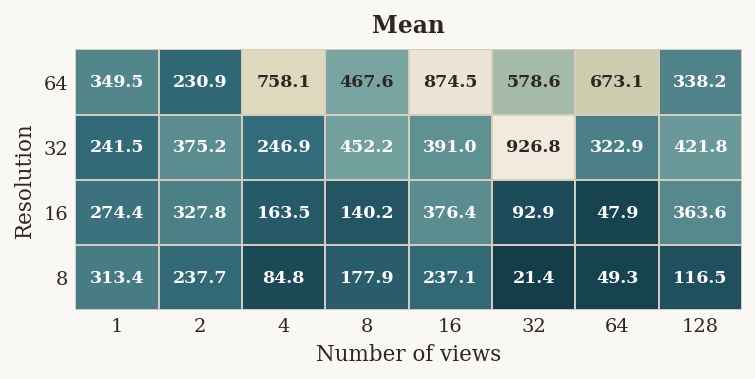

In [51]:
# Heatmap of performance over res and k_views with refined styling
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

PAPER_BG = "#f9f8f5"
AXIS_BG = "#ffffff"
GRID_COLOR = "#d8cec0"
TEXT_COLOR = "#2d2622"
MISSING_COLOR = "#efe7dc"
# HEATMAP_CMAP = LinearSegmentedColormap.from_list(
#     "as_bbo_heatmap",
#     ["#f3eadf", "#d9d7c8", "#89aaa6", "#396e7b", "#143d4a"],
# )
HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "as_bbo_heatmap",
    ["#143d4a", "#336c7a", "#7aa7a2", "#d7d3b1", "#f3eadf"],
)
HEATMAP_CMAP.set_bad(MISSING_COLOR)

mpl.rcParams.update(
    {
        "figure.facecolor": PAPER_BG,
        "axes.facecolor": AXIS_BG,
        "axes.edgecolor": AXIS_BG,
        "axes.labelcolor": TEXT_COLOR,
        "axes.titlecolor": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "text.color": TEXT_COLOR,
        "font.family": "DejaVu Serif",
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 140,
        "savefig.dpi": 240,
        "savefig.facecolor": PAPER_BG,
        "savefig.bbox": "tight",
    }
)

def _format_cell_value(value: float) -> str:
    magnitude = abs(value)
    if magnitude >= 1000 or (0 < magnitude < 0.01):
        return f"{value:.1e}"
    if magnitude >= 10:
        return f"{value:.1f}"
    return f"{value:.3g}"

def _text_color_from_tile(im: mpl.image.AxesImage, value: float) -> str:
    red, green, blue, _ = im.cmap(im.norm(value))
    luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
    return AXIS_BG if luminance < 0.6 else TEXT_COLOR

def plot_heatmap_with_labels(
    value_col: str,
    title: str,
    output_path: Optional[str] = None,
    cbar_range: Optional[Tuple[float, float]] = None,
    cmap: Optional[mpl.colors.Colormap] = None,
    swap_axes: bool = True,
    figsize: Optional[Tuple[float, float]] = None,
) -> None:
    if swap_axes:
        pivot = df_compiled.pivot_table(index="res", columns="k_views", values=value_col, aggfunc="mean")
        x_label = "Number of views"
        y_label = "Resolution"
        figure_size = figsize or (5.5, 3.0)
    else:
        pivot = df_compiled.pivot_table(index="k_views", columns="res", values=value_col, aggfunc="mean")
        x_label = "Resolution"
        y_label = "Number of views"
        figure_size = figsize or (4, 5)

    pivot = pivot.sort_index().sort_index(axis=1)
    data = np.ma.masked_invalid(pivot.values.astype(float))

    fig, ax = plt.subplots(figsize=figure_size)
    im = ax.imshow(
        data,
        aspect="auto",
        origin="lower",
        cmap=cmap or HEATMAP_CMAP,
        interpolation="nearest",
    )

    if cbar_range is not None:
        im.set_clim(*cbar_range)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(int))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(int))
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    ax.set_xticks(np.arange(-0.5, len(pivot.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
    ax.grid(which="minor", color=GRID_COLOR, linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            value = pivot.values[y, x]
            if np.isnan(value):
                continue
            ax.text(
                x,
                y,
                _format_cell_value(value),
                ha="center",
                va="center",
                color=_text_color_from_tile(im, value),
                fontsize=9,
                fontweight="semibold",
            )

    ax.set_title(
        f"{title}",
        y=1.02,
        fontsize=12,
        fontweight="semibold",
    )

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    if output_path is not None:
        output_dir = Path(output_path)
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / f"{protocol}_{value_col}_heatmap.svg")
    plt.show()

plot_heatmap_with_labels("mean", "Mean", output_path='')

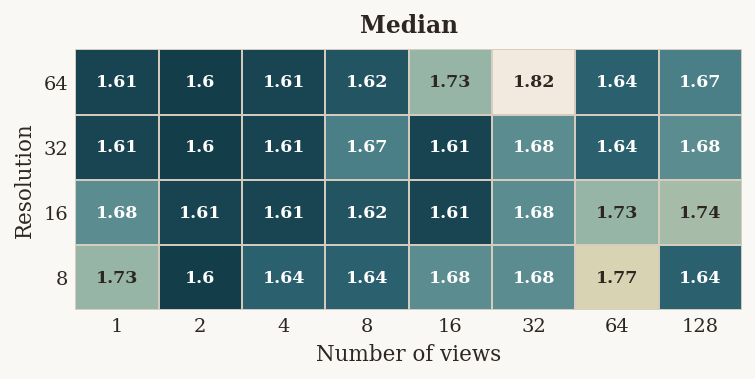

In [52]:
plot_heatmap_with_labels("median", "Median", output_path='')

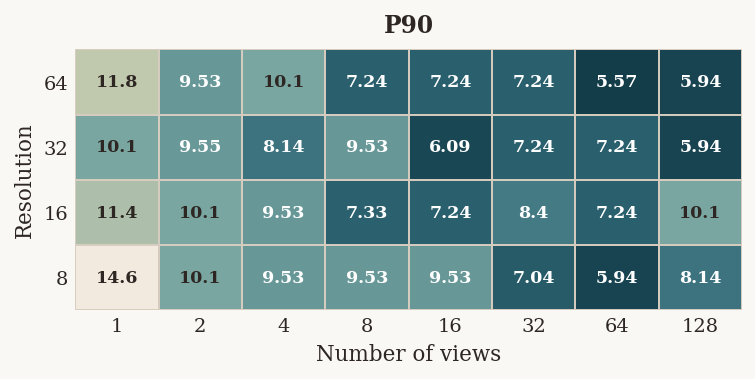

In [53]:
plot_heatmap_with_labels("p90", "P90", output_path='')

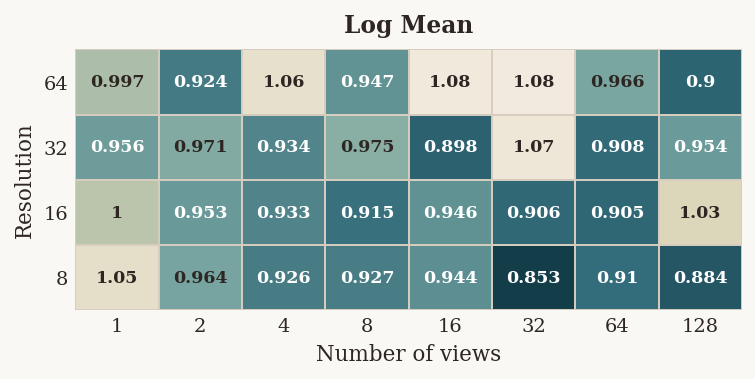

In [54]:
plot_heatmap_with_labels("log_mean", "Log Mean")

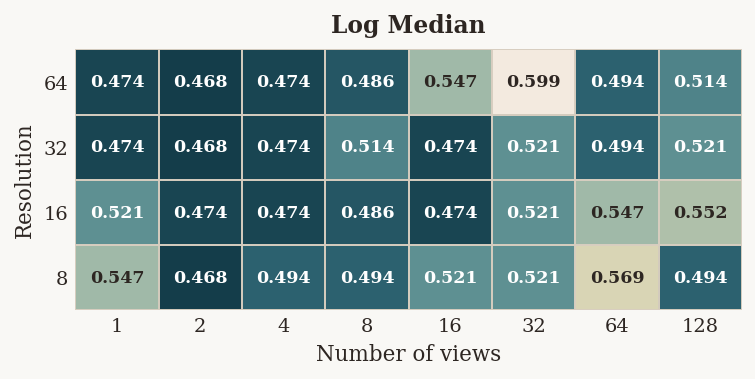

In [55]:
plot_heatmap_with_labels("log_median", "Log Median")

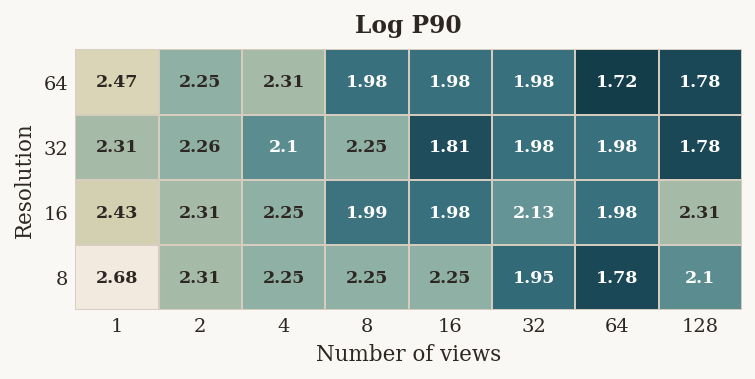

In [56]:
plot_heatmap_with_labels("log_p90", "Log P90")